In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_palette('colorblind')

In [9]:
good_pairs = pd.read_csv('./parsing_v2/2026_05_08_filtered_BC_VR_table.csv.xz')
good_pairs

/var/folders/5_/tjkj20xs1zjbm1r6n07ccp4h0000gn/T/ipykernel_37993/1690566076.py:1: DtypeWarning: Columns (0: lib004_junction) have mixed types. Specify dtype option on import or set low_memory=False.
  good_pairs = pd.read_csv('./parsing_v2/2026_05_08_filtered_BC_VR_table.csv.xz')


,Unnamed: 0,index,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction,library_assignment,Read_count,keep_mask
0,0,0,bc2011,A,CTCACATACAATAGTTAAGC,TCAGTCCTAACTTAATTTCCATATCTACTGGTTATGGTTTATTCAC...,AGAGCCGAATTGCAGTTGATTAGAAGTAATAGTACACTAT,NaN,NaN,NaN,NaN,lib1,1,True
1,1,1,bc2011,A,CTTACACTCGTAAAAACGAG,CGTTTAGGGAGAAAGTGGACGTTGTACATATCTCACGTGCAGCATC...,TGGCCTTTGGTTTTGCTTTTTTATTACTATCCTACTAAAG,NaN,NaN,NaN,NaN,lib1,1,True
2,2,2,bc2011,A,TAGAAGTGTACGGTTCTGGA,CTGACCTCCTTAAAAAAAATTGCACTGTCTTTTTGAACAGTATCCC...,ATGTATGGGCTAGCCTTTATCCCCAGTACAGTTTCGGTCT,NaN,NaN,NaN,NaN,lib1,3,True
3,3,3,bc2011,A,TGCCAAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,7,True
4,4,4,bc2011,A,TGCCAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662326,2453049,2453049,unassigned,TTTTTT,GAGATTCCCAAGCATGACCA,TGGCTACATCTTTTTTGATTTTCGATAGGGTTGATCTTCTAAGTTC...,GTTTGGAGTTCTACTCACAAGGGTTGGATATCGACTCTGC,NaN,NaN,NaN,NaN,lib1,1,True
1662327,2453050,2453050,unassigned,TTTTTT,GTACTGTCTCCCTTGTGGGC,NaN,NaN,TAGGTGTTTCGGGAACTATAATATGGGTTCGGCCTTTCTGCAATTG...,TGGACGTTTAGACTGCGGTGGAGTCTATTCTTAGGCATT,NaN,NaN,lib2,1,True
1662328,2453051,2453051,unassigned,TTTTTT,TGCAATCGTCTCAACAGCGC,GAGTGTTATGTTGTTTAATGTCACTGGAATTATTTCTAATATTCTA...,ATGTCTGGGCTTCATCTGCTCGTTCCGTTTGGAGACACCT,NaN,NaN,NaN,NaN,lib1,1,True
1662329,2453052,2453052,unassigned,TTTTTT,TTTAAACCGTTTTTTACCGAT,NaN,NaN,GGAATATATTTTTTGACGCTCACCGGCAAGTGATTACTCGTAGCTA...,TTTATTCTCTTACTTTAAACAGAATGGAGCCTTATGTTTC,NaN,NaN,lib2,1,True


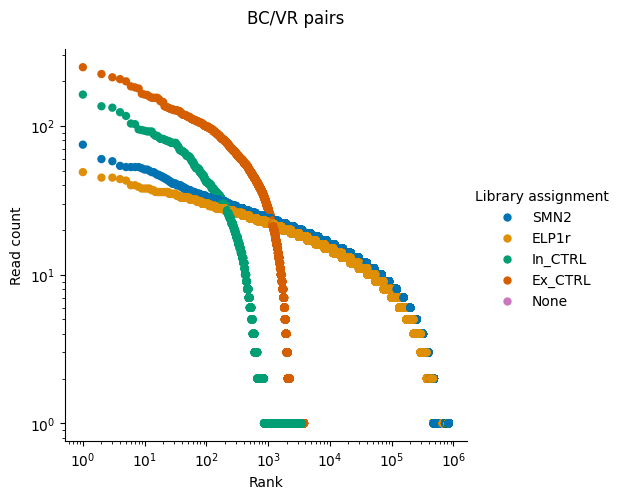

In [10]:
data_df = good_pairs.copy().rename(columns={
        'Read_count':'Read count',
        'library_assignment':'Library assignment'
    }).replace({
        'lib1':'SMN2',
        'lib2':'ELP1r',
        'lib3':'In_CTRL',
        'lib4':'Ex_CTRL',
    })
y_col = 'Read count'
title = 'BC/VR pairs'
group_cols = ['Library assignment']
hue_order=['SMN2', 'ELP1r', 'In_CTRL', 'Ex_CTRL', 'None']
col_order=['bc2011', 'bc2015', 'unassigned']

to_plot = data_df.sort_values(y_col, ascending=False)
to_plot['Rank'] = to_plot.groupby(group_cols)[y_col].rank(method='first', ascending=False)
g = sns.relplot(data=to_plot, x="Rank", y=y_col,  kind='scatter', hue='Library assignment', hue_order=hue_order, #col_order=col_order, col="file_name",
                edgecolor='none')
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.subplots_adjust(top=0.9)
plt.suptitle(title)
plt.show()

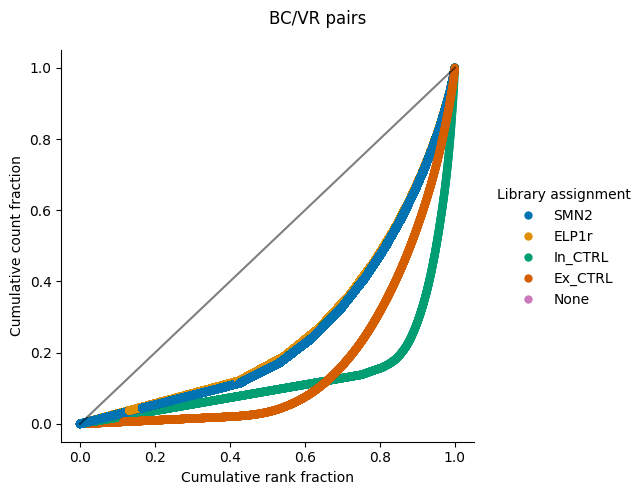

gini coefficient


,Library assignment,Gini coefficient
0,ELP1r,0.472453
1,Ex_CTRL,0.674183
2,In_CTRL,0.734518
3,SMN2,0.483716


In [11]:
data_df = good_pairs.copy().rename(columns={
        'Read_count':'Read count',
        'library_assignment':'Library assignment'
    }).replace({
        'lib1':'SMN2',
        'lib2':'ELP1r',
        'lib3':'In_CTRL',
        'lib4':'Ex_CTRL',
    })
y_col = 'Read count'
title = 'BC/VR pairs'
group_cols = ['Library assignment']
hue_order=['SMN2', 'ELP1r', 'In_CTRL', 'Ex_CTRL', 'None']
col_order=['bc2011', 'bc2015', 'unassigned']

to_plot = data_df.copy().sort_values(y_col, ascending=True)
to_plot['Cumulative count fraction'] = to_plot.groupby(group_cols, group_keys=False)[y_col].apply(lambda x: x.cumsum()/x.sum())
to_plot['Cumulative rank fraction'] = to_plot.groupby(group_cols)[y_col].rank(method='first', ascending=True).sort_values().groupby([to_plot[col] for col in group_cols], group_keys=False).apply(lambda x: x/(len(x)))

g = sns.relplot(data=to_plot, x="Cumulative rank fraction", y="Cumulative count fraction", kind='scatter', hue='Library assignment', hue_order=hue_order, 
                # col_order=col_order,col="file_name",
                edgecolor='none')
g.map_dataframe(lambda *args, **kwargs: plt.plot([0, 1], [0, 1], color='black', alpha=0.5))
plt.subplots_adjust(top=0.9)
plt.suptitle(title)
plt.show()
def gini(sorted_arr):
    n = sorted_arr.size
    coef_ = 2. / n
    const_ = (n + 1.) / n
    weighted_sum = sum([(i+1)*yi for i, yi in enumerate(sorted_arr)])
    return coef_*weighted_sum/(sorted_arr.sum()) - const_

print('gini coefficient')
display(to_plot.groupby(group_cols)[y_col].apply(gini).rename('Gini coefficient').reset_index())

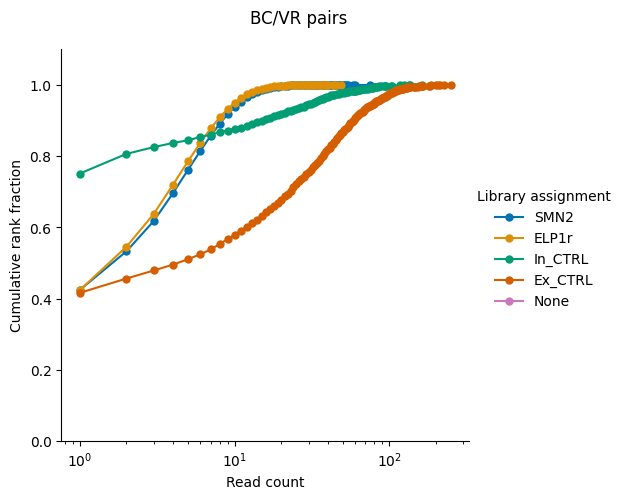

In [22]:
data_df = good_pairs.copy().rename(columns={
        'Read_count':'Read count',
        'library_assignment':'Library assignment'
    }).replace({
        'lib1':'SMN2',
        'lib2':'ELP1r',
        'lib3':'In_CTRL',
        'lib4':'Ex_CTRL',
    })
y_col = 'Read count'
title = 'BC/VR pairs'
group_cols = ['Library assignment']
hue_order=['SMN2', 'ELP1r', 'In_CTRL', 'Ex_CTRL', 'None']
col_order=['bc2011', 'bc2015', 'unassigned']

to_plot = data_df.sort_values(y_col, ascending=False)
to_plot['Cumulative rank fraction'] = to_plot.groupby(group_cols)[y_col].rank(method='first', ascending=True).sort_values().groupby([to_plot[col] for col in group_cols], group_keys=False).apply(lambda x: x/(len(x)))

g = sns.relplot(data=to_plot, y="Cumulative rank fraction", x=y_col, kind='line',
                hue='Library assignment', hue_order=hue_order, marker='o',
                estimator='max', errorbar=None, markeredgecolor='none')
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_ylim(0, 1.1)
    # ax.set_yscale('log')
plt.subplots_adjust(top=0.9)
plt.suptitle(title)
plt.show()

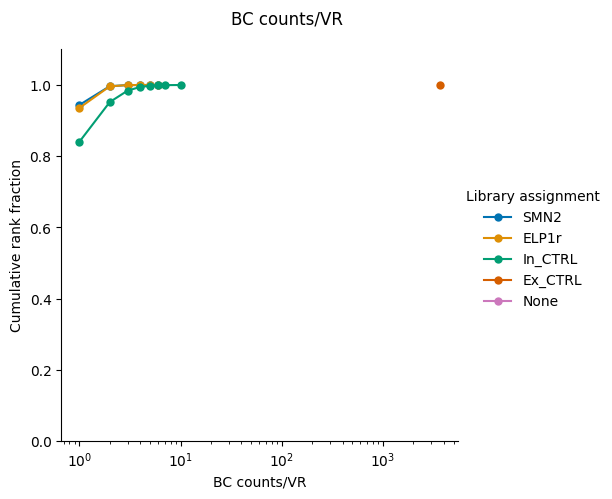

In [26]:
to_plot = good_pairs.copy()
to_plot['BC'] = to_plot['upstream_barcode']+to_plot['downstream_barcode']
data_df = to_plot.groupby(['library_assignment', 'lib001_variable_exon','lib001_variable_intron','lib002_variable_exon','lib002_variable_intron','lib003_variable_exon','lib004_junction'], dropna=False)['BC'].nunique().rename('BC_count').reset_index().rename(columns={
        'BC_count':'BC counts/VR',
        'library_assignment':'Library assignment'
    }).replace({
        'lib1':'SMN2',
        'lib2':'ELP1r',
        'lib3':'In_CTRL',
        'lib4':'Ex_CTRL',
    })
y_col = 'BC counts/VR'
title = 'BC counts/VR'
group_cols = ['Library assignment']
hue_order=['SMN2', 'ELP1r', 'In_CTRL', 'Ex_CTRL', 'None']
col_order=['bc2011', 'bc2015', 'unassigned']

to_plot = data_df.sort_values(y_col, ascending=False)
to_plot['Cumulative rank fraction'] = to_plot.groupby(group_cols)[y_col].rank(method='first', ascending=True).sort_values().groupby([to_plot[col] for col in group_cols], group_keys=False).apply(lambda x: x/(len(x)))

g = sns.relplot(data=to_plot, y="Cumulative rank fraction", x=y_col,  kind='line',
                hue='Library assignment', hue_order=hue_order, marker='o',
                estimator='max', errorbar=None, markeredgecolor='none')
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_ylim(0, 1.1)
plt.subplots_adjust(top=0.9)
plt.suptitle(title)
plt.show()

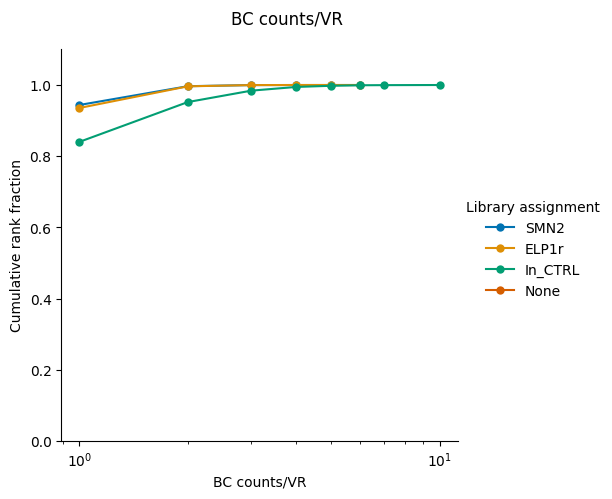

In [25]:
to_plot = good_pairs.copy()
to_plot['BC'] = to_plot['upstream_barcode']+to_plot['downstream_barcode']
data_df = to_plot.groupby(['library_assignment', 'lib001_variable_exon','lib001_variable_intron','lib002_variable_exon','lib002_variable_intron','lib003_variable_exon','lib004_junction'], dropna=False)['BC'].nunique().rename('BC_count').reset_index().rename(columns={
        'BC_count':'BC counts/VR',
        'library_assignment':'Library assignment'
    }).replace({
        'lib1':'SMN2',
        'lib2':'ELP1r',
        'lib3':'In_CTRL',
        'lib4':'Ex_CTRL',
    })
data_df=data_df[data_df['Library assignment']!='Ex_CTRL']
y_col = 'BC counts/VR'
title = 'BC counts/VR'
group_cols = ['Library assignment']
hue_order=['SMN2', 'ELP1r', 'In_CTRL', 'None']
col_order=['bc2011', 'bc2015', 'unassigned']

to_plot = data_df.sort_values(y_col, ascending=False)
to_plot['Cumulative rank fraction'] = to_plot.groupby(group_cols)[y_col].rank(method='first', ascending=True).sort_values().groupby([to_plot[col] for col in group_cols], group_keys=False).apply(lambda x: x/(len(x)))

g = sns.relplot(data=to_plot, y="Cumulative rank fraction", x=y_col,  kind='line',
                hue='Library assignment', hue_order=hue_order, marker='o',
                estimator='max', errorbar=None, markeredgecolor='none')
for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.set_ylim(0, 1.1)
plt.subplots_adjust(top=0.9)
plt.suptitle(title)
plt.show()